# LMCF — Exploratory Plots
All plots use **val set metrics**. Run `analyze.py` and `inference_metrics.py` first.


In [23]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
LMCF_ROOT = '.'
os.environ["LMCF_ROOT"] = LMCF_ROOT

PROJECT_ROOT = os.environ.get('LMCF_ROOT', os.path.expanduser('~/lmcf_project'))
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'Results')
FIG_DIR = os.path.join(PROJECT_ROOT, 'figures')

MODELS       = ['M1', 'M2', 'M3']
MODEL_PARAMS = {'M1':'', 'M2':'', 'M3':''}   # millions of parameters
COLORS       = {'M1': '#2196F3', 'M2': '#FF9800', 'M3': '#4CAF50'}
EXPS         = ['E1', 'E2', 'E3']

# ── Load all result files ──────────────────────────────────────────────────────
metrics   = pd.read_csv(os.path.join(RESULTS_DIR, 'metrics_summary.csv'))
speed     = pd.read_csv(os.path.join(RESULTS_DIR, 'learning_speed.csv'))
wchange   = pd.read_csv(os.path.join(RESULTS_DIR, 'weight_change_summary.csv'))
coverage  = pd.read_csv(os.path.join(RESULTS_DIR, 'concept_coverage.csv'))
bertscore = pd.read_csv(os.path.join(RESULTS_DIR, 'bertscore.csv'))

print('Loaded files:')
print(f'  metrics   : {metrics.shape}')
print(f'  speed     : {speed.shape}')
print(f'  wchange   : {wchange.shape}')
print(f'  coverage  : {coverage.shape}')
print(f'  bertscore : {bertscore.shape}')
print(f'\nModels available: {metrics["model"].tolist()}')


Loaded files:
  metrics   : (3, 35)
  speed     : (15, 10)
  wchange   : (30, 4)
  coverage  : (12, 9)
  bertscore : (12, 11)

Models available: ['M1', 'M2', 'M3']


In [16]:
metrics

,model,E1_s1_ppl_a,E1_s1_ppl_b,E1_s2_ppl_a,E1_s2_ppl_b,E2_ppl_a,E2_ppl_b,E3_s1_ppl_a,E3_s1_ppl_b,E3_s2_ppl_a,...,FWT_B_test,FWT_A_test,FWT_B_norm_val,FWT_A_norm_val,FWT_B_norm_test,FWT_A_norm_test,Gap_A_val,Gap_B_val,Gap_A_test,Gap_B_test
0,M1,19.740686,22708.341857,413.593705,92.696255,25.358548,150.302665,1040.793509,115.539749,16.075142,...,-23.4336,-3.7918,-0.1977,-0.1857,-0.1997,-0.1877,388.2352,5748.2744,392.0991,5667.7491
1,M2,12.727815,9606.715967,259.482127,53.406263,17.068582,100.666344,814.407101,73.062436,10.284625,...,-20.3096,-2.3901,-0.2690,-0.1920,-0.2713,-0.1923,242.4135,6914.1554,242.3959,6897.7209
2,M3,12.179901,6956.102904,195.146834,50.450878,16.867437,105.474921,744.514368,76.075684,9.563655,...,-25.3793,-2.5728,-0.3368,-0.2148,-0.3360,-0.2126,178.2794,2778.9696,180.1299,2773.1722


## Plot 1 — Forgetting Scores by Scale (RQ3)
BWT_A (E1) and BWT_B (E3) vs model size. Positive = forgetting occurred.

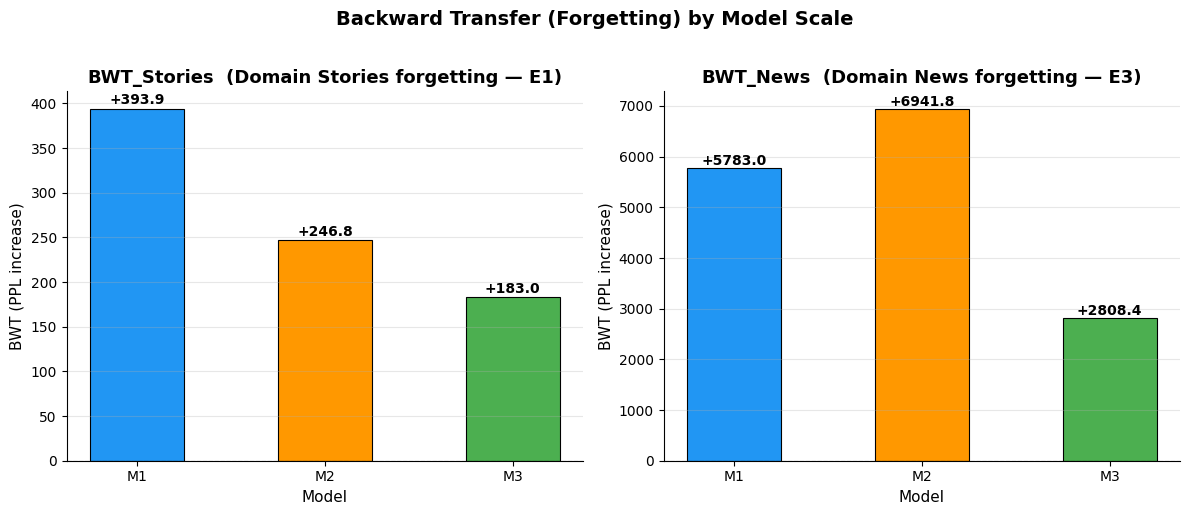

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

params = [MODEL_PARAMS[m] for m in metrics['model']]

for ax, col, title, color in [
    (axes[0], 'BWT_A_val', 'BWT_Stories  (Domain Stories forgetting — E1)', '#E53935'),
    (axes[1], 'BWT_B_val', 'BWT_News  (Domain News forgetting — E3)', '#1E88E5'),
]:
    vals = metrics[col].tolist()
    
    bars = ax.bar(metrics['model'], vals, color=[COLORS[m] for m in metrics['model']],
                  edgecolor='black', linewidth=0.8, width=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('BWT (PPL increase)', fontsize=11)
    ax.set_xticks(range(len(metrics)))
    # ax.set_xticklabels([f'{m}\n({MODEL_PARAMS[m]}M)' for m in metrics['model']])
    # Annotate bars
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{val:+.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Backward Transfer (Forgetting) by Model Scale', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot1_forgetting_scale.png'), dpi=150, bbox_inches='tight')
plt.show()


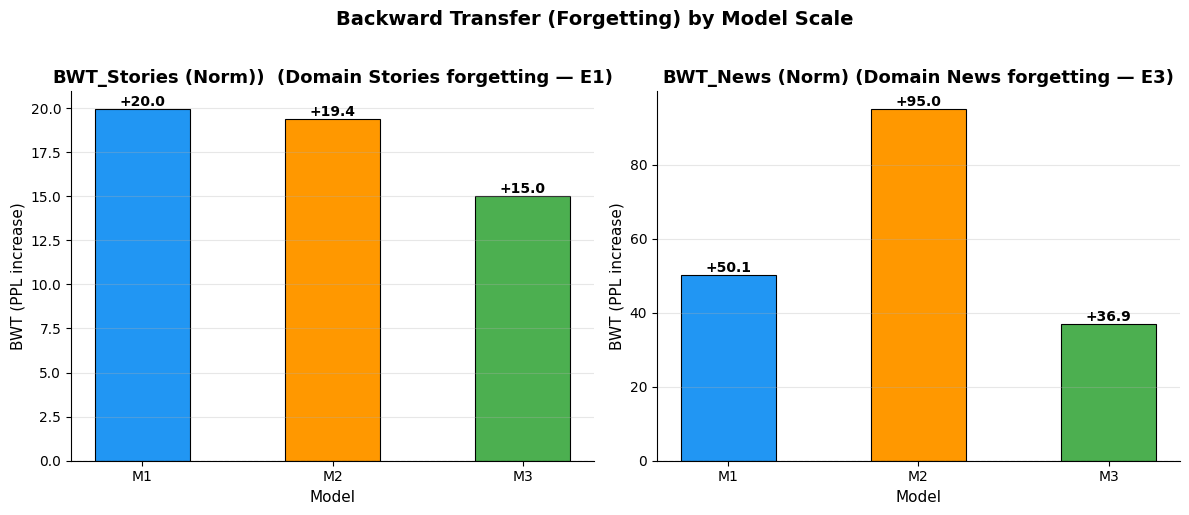

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

params = [MODEL_PARAMS[m] for m in metrics['model']]

for ax, col, title, color in [
    (axes[0], 'BWT_A_norm_val', 'BWT_Stories (Norm))  (Domain Stories forgetting — E1)', '#E53935'),
    (axes[1], 'BWT_B_norm_val', 'BWT_News (Norm) (Domain News forgetting — E3)', '#1E88E5'),
]:
    vals = metrics[col].tolist()
    
    bars = ax.bar(metrics['model'], vals, color=[COLORS[m] for m in metrics['model']],
                  edgecolor='black', linewidth=0.8, width=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('BWT (PPL increase)', fontsize=11)
    ax.set_xticks(range(len(metrics)))
    # ax.set_xticklabels([f'{m}\n({MODEL_PARAMS[m]}M)' for m in metrics['model']])
    # Annotate bars
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{val:+.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Backward Transfer (Forgetting) by Model Scale', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot1_forgetting_scale_norm.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 2 — Retention Rate vs Scale
1.0 = perfect retention. Lower = more forgetting.

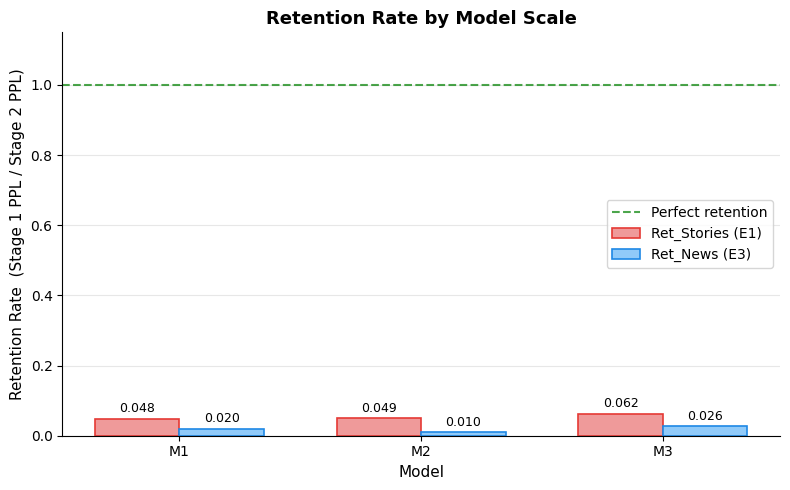

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

x      = np.arange(len(metrics))
width  = 0.35
params = [MODEL_PARAMS[m] for m in metrics['model']]

b1 = ax.bar(x - width/2, metrics['Ret_A_val'], width, label='Ret_Stories (E1)',
            color='#EF9A9A', edgecolor='#E53935', linewidth=1.2)
b2 = ax.bar(x + width/2, metrics['Ret_B_val'], width, label='Ret_News (E3)',
            color='#90CAF9', edgecolor='#1E88E5', linewidth=1.2)

ax.axhline(1.0, color='green', linewidth=1.5, linestyle='--', alpha=0.7, label='Perfect retention')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Retention Rate  (Stage 1 PPL / Stage 2 PPL)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Retention Rate by Model Scale', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}' for m in metrics['model']])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot2_retention.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 3 — Asymmetry: Is Forgetting Symmetric? (RQ2)
BWT_A (A forgotten after B training) vs BWT_B (B forgotten after A training) per model.

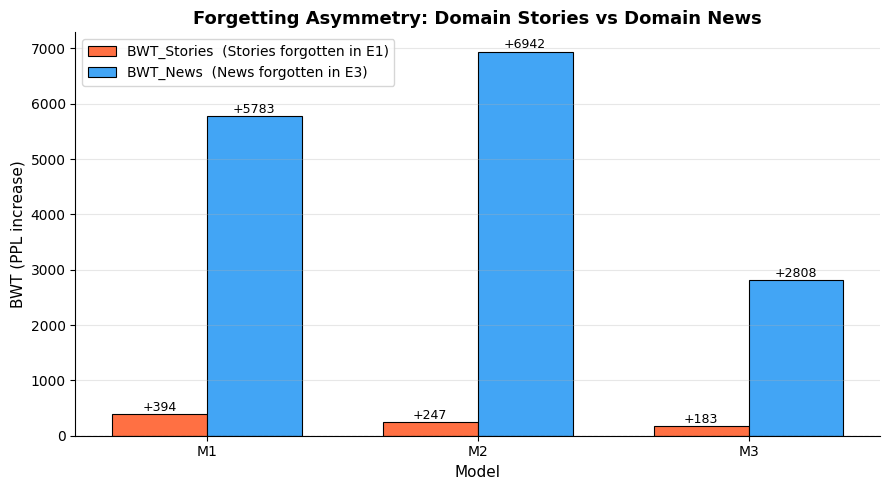

In [61]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(metrics))
width = 0.35

b1 = ax.bar(x - width/2, metrics['BWT_A_val'], width,
            label='BWT_Stories  (Stories forgotten in E1)', color='#FF7043',
            edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + width/2, metrics['BWT_B_val'], width,
            label='BWT_News  (News forgotten in E3)', color='#42A5F5',
            edgecolor='black', linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('BWT (PPL increase)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Forgetting Asymmetry: Domain Stories vs Domain News', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}' for m in metrics['model']])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                    f'{h:+.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot3_asymmetry.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 4 — Mixed Gap: Cost of Sequential vs Joint Training
How much worse is E1/E3 compared to E2 (mixed). Positive = sequential worse.

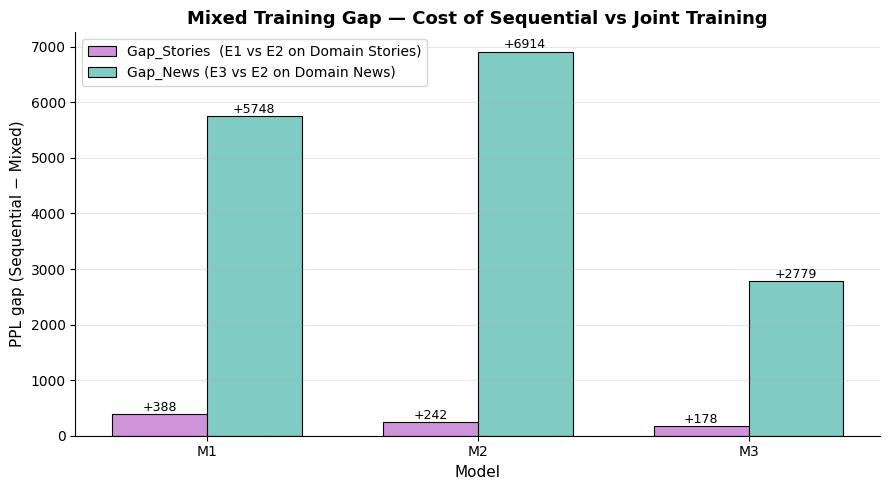

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(metrics))
width = 0.35

b1 = ax.bar(x - width/2, metrics['Gap_A_val'], width,
            label='Gap_Stories  (E1 vs E2 on Domain Stories)', color='#CE93D8',
            edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + width/2, metrics['Gap_B_val'], width,
            label='Gap_News (E3 vs E2 on Domain News)', color='#80CBC4',
            edgecolor='black', linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylabel('PPL gap (Sequential − Mixed)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Mixed Training Gap — Cost of Sequential vs Joint Training', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}' for m in metrics['model']])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + (1 if h >= 0 else -5),
                    f'{h:+.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot4_mixed_gap.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 5 — Forward Transfer
Did pretraining on one domain help learn the other? Negative = positive transfer.

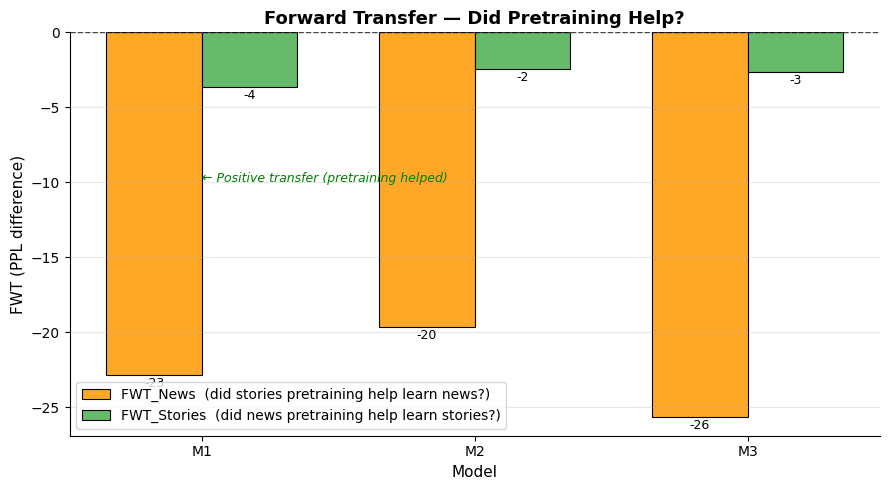

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(metrics))
width = 0.35

b1 = ax.bar(x - width/2, metrics['FWT_B_val'], width,
            label='FWT_News  (did stories pretraining help learn news?)', color='#FFA726',
            edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + width/2, metrics['FWT_A_val'], width,
            label='FWT_Stories  (did news pretraining help learn stories?)', color='#66BB6A',
            edgecolor='black', linewidth=0.8)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.annotate('← Positive transfer (pretraining helped)',
            xy=(0, -10), fontsize=9, color='green', style='italic')

ax.set_ylabel('FWT (PPL difference)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Forward Transfer — Did Pretraining Help?', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}' for m in metrics['model']])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            offset = 1 if h >= 0 else -1
            ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                    f'{h:+.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot5_fwt.png'), dpi=150, bbox_inches='tight')
plt.show()


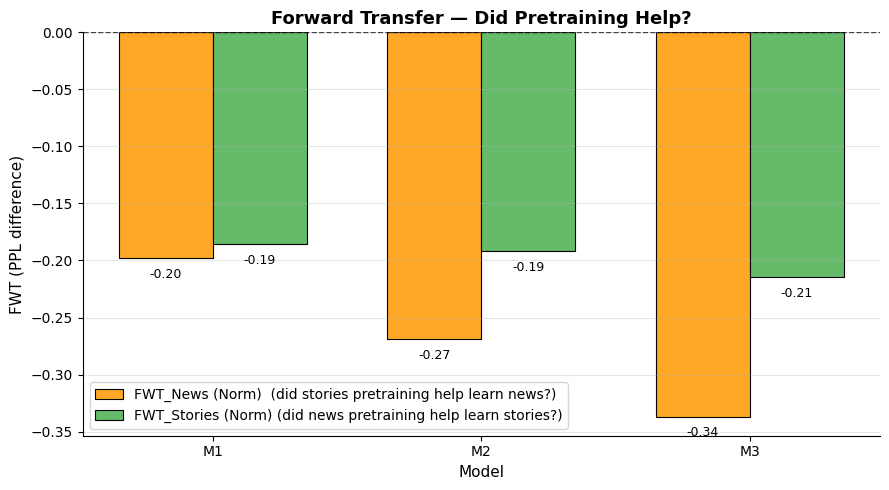

In [67]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(metrics))
width = 0.35

b1 = ax.bar(x - width/2, metrics['FWT_B_norm_val'], width,
            label='FWT_News (Norm)  (did stories pretraining help learn news?)', color='#FFA726',
            edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + width/2, metrics['FWT_A_norm_val'], width,
            label='FWT_Stories (Norm) (did news pretraining help learn stories?)', color='#66BB6A',
            edgecolor='black', linewidth=0.8)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.annotate('← Positive transfer (pretraining helped)',
            xy=(0, -10), fontsize=9, color='green', style='italic')

ax.set_ylabel('FWT (PPL difference)', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Forward Transfer — Did Pretraining Help?', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}' for m in metrics['model']])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            offset = 1 if h >= 0 else -1
            ax.text(bar.get_x() + bar.get_width()/2, h-0.02,
                    f'{h:+.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot5_fwt_norm.png'), dpi=150, bbox_inches='tight')
plt.show()

## Plot 6 — Learning Speed by Model Scale
Steps to reach each PPL threshold. Lower = faster convergence.

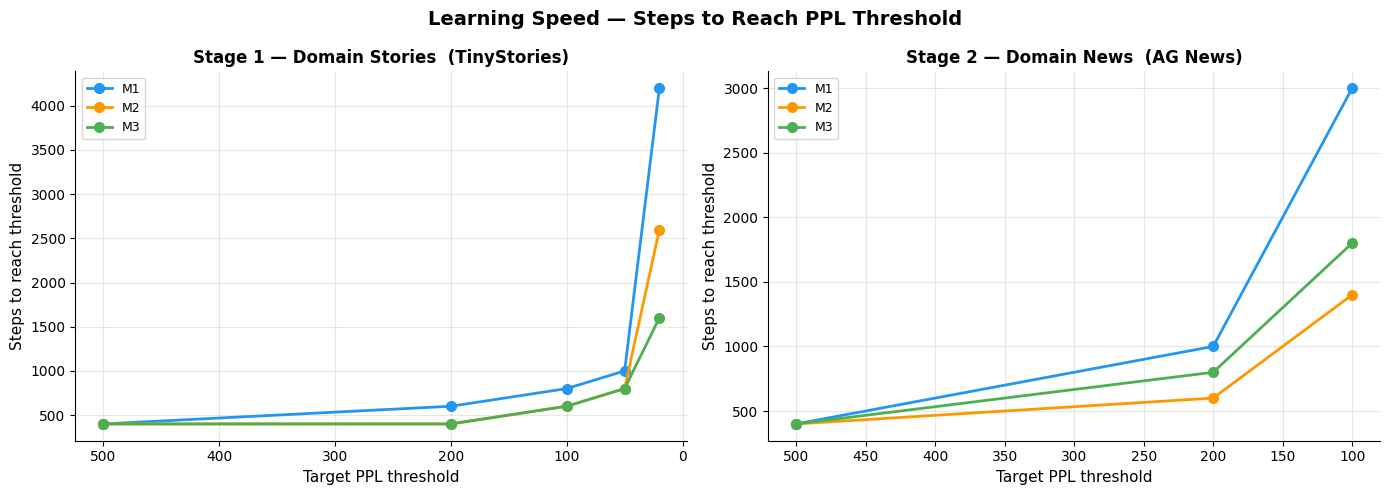

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
thresholds = [500, 200, 100, 50, 20]
thresh_cols = [f'steps_to_ppl{t}' for t in thresholds]

for ax, (exp, stage_filter, title) in zip(axes, [
    ('E1', 'after_A',         'Stage 1 — Domain Stories  (TinyStories)'),
    ('E1', 'after_A_then_B',  'Stage 2 — Domain News  (AG News)'),
]):
    sub = speed[(speed['experiment'] == exp) & (speed['stage'] == stage_filter)]
    for _, row in sub.iterrows():
        model = row['model']
        vals  = [row.get(c, np.nan) for c in thresh_cols]
        ax.plot(thresholds, vals, marker='o', linewidth=2,
                color=COLORS[model], label=f'{model}',
                markersize=7)

    ax.set_xlabel('Target PPL threshold', fontsize=11)
    ax.set_ylabel('Steps to reach threshold', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.invert_xaxis()
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Learning Speed — Steps to Reach PPL Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot6_learning_speed.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 7 — Weight Change Magnitude by Layer Type
Avg relative change per layer type. Shows WHERE in the model forgetting happens.

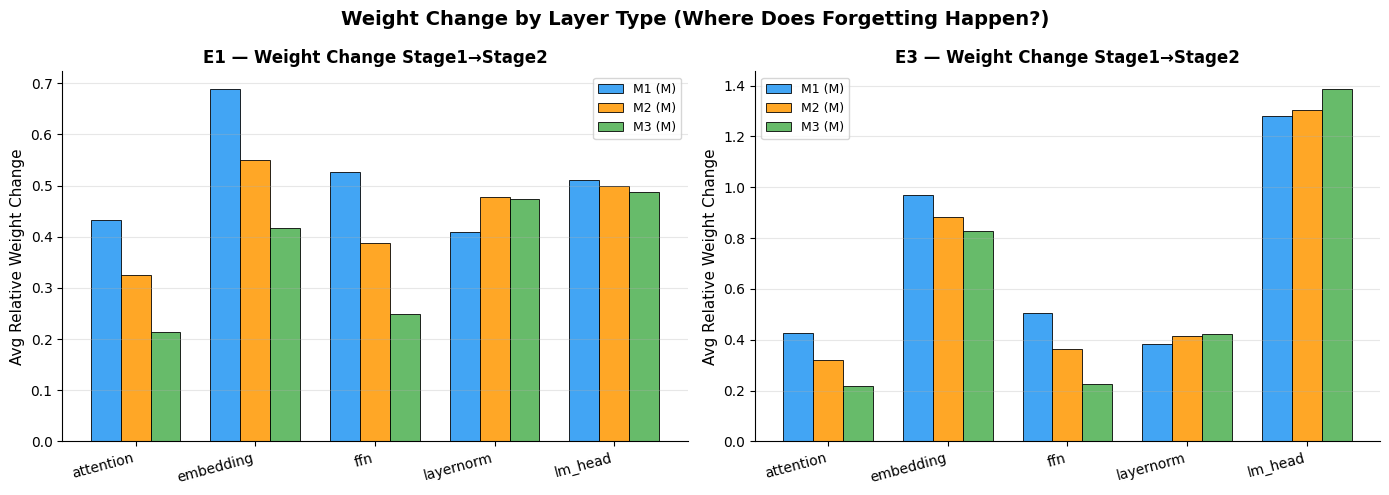

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layer_colors = {
    'embedding': '#42A5F5', 'attention': '#EF5350',
    'ffn': '#FF7043',       'layernorm': '#AB47BC',
    'lm_head': '#26A69A',   'other': '#BDBDBD',
}

for ax, exp in zip(axes, ['E1', 'E3']):
    sub    = wchange[wchange['experiment'] == exp]
    layers = sorted(sub['layer_type'].unique())
    x      = np.arange(len(layers))
    width  = 0.25
    offsets = np.linspace(-(len(MODELS)-1)*width/2, (len(MODELS)-1)*width/2, len(MODELS))

    for offset, model in zip(offsets, MODELS):
        row  = sub[sub['model'] == model]
        vals = [row[row['layer_type'] == l]['avg_rel_change'].values[0]
                if len(row[row['layer_type'] == l]) > 0 else np.nan
                for l in layers]
        ax.bar(x + offset, vals, width, label=f'{model} ({MODEL_PARAMS[model]}M)',
               color=COLORS[model], edgecolor='black', linewidth=0.7, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(layers, rotation=15, ha='right')
    ax.set_ylabel('Avg Relative Weight Change', fontsize=11)
    ax.set_title(f'{exp} — Weight Change Stage1→Stage2', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Weight Change by Layer Type (Where Does Forgetting Happen?)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot7_weight_change.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 8 — Concept Coverage Across Stages
`cov_a_on_Aprompts` dropping = forgetting of A-style vocabulary. Split by experiment.

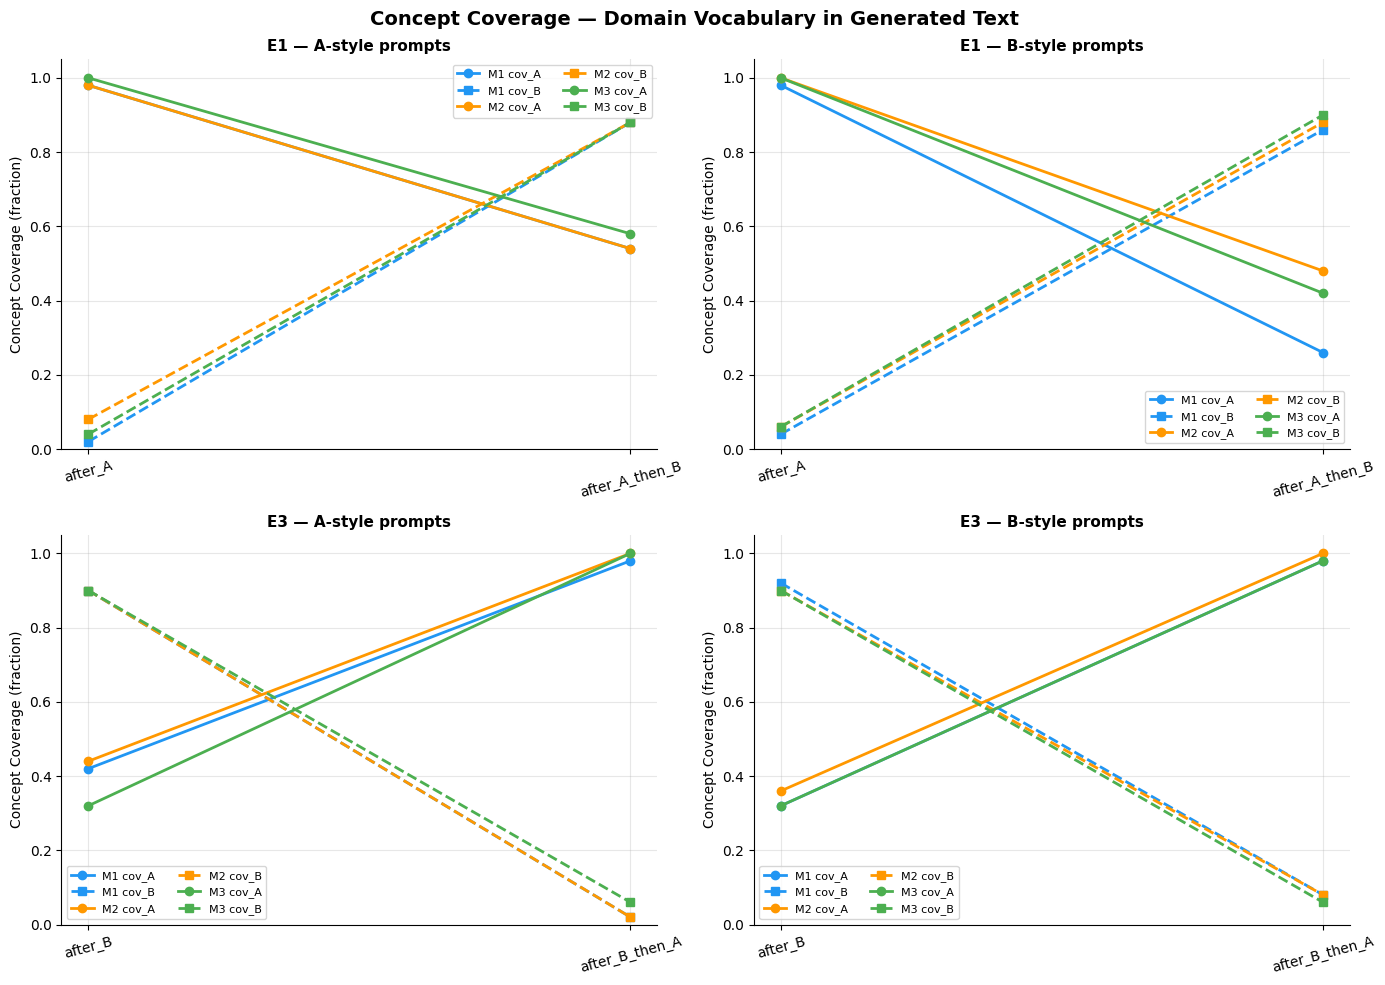

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, exp in enumerate(['E1', 'E3']):
    sub       = coverage[coverage['experiment'] == exp]
    forget_d  = 'A' if exp == 'E1' else 'B'
    learn_d   = 'B' if exp == 'E1' else 'A'

    for col_idx, (col_a, col_b, prompt_type) in enumerate([
        ('cov_a_on_Aprompts', 'cov_b_on_Aprompts', f'A-style prompts'),
        ('cov_a_on_Bprompts', 'cov_b_on_Bprompts', f'B-style prompts'),
    ]):
        ax = axes[row_idx][col_idx]
        stages = sub['stage'].tolist()

        for model in MODELS:
            mrow = sub[sub['model'] == model] if 'model' in sub.columns else sub
            if len(mrow) == 0:
                continue
            ax.plot(mrow['stage'], mrow[col_a], marker='o', linewidth=2,
                    color=COLORS[model], linestyle='-',
                    label=f'{model} cov_A')
            ax.plot(mrow['stage'], mrow[col_b], marker='s', linewidth=2,
                    color=COLORS[model], linestyle='--',
                    label=f'{model} cov_B')

        ax.set_title(f'{exp} — {prompt_type}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Concept Coverage (fraction)', fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle('Concept Coverage — Domain Vocabulary in Generated Text',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot8_concept_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 9 — BERTScore: Semantic Similarity Stage 1 → Stage 2
F1 < 0.70 = high semantic drift. Split by prompt type.

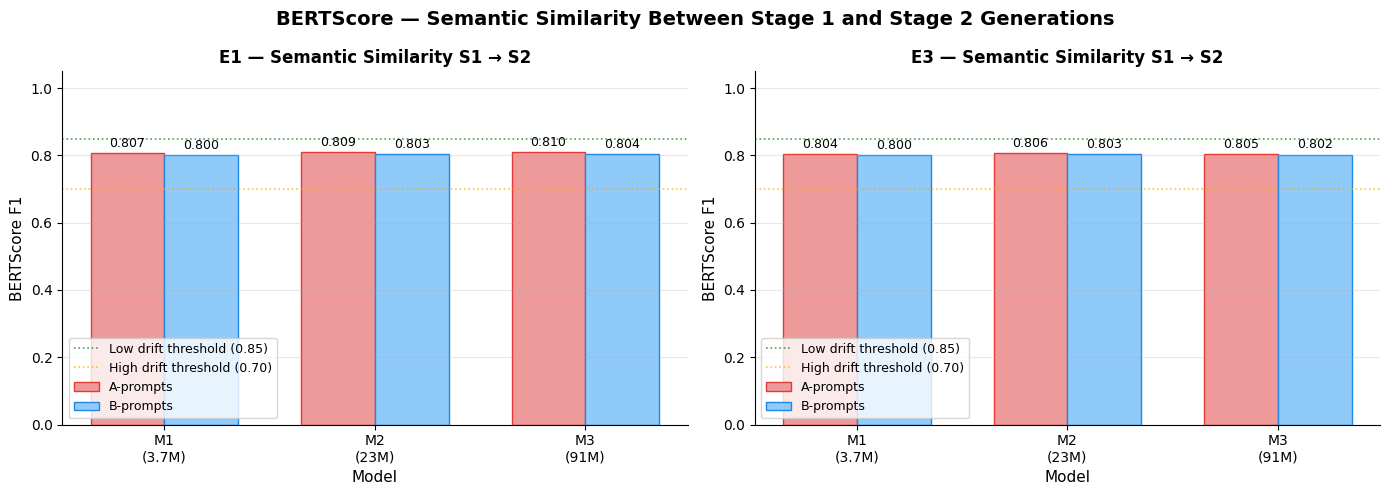

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp in zip(axes, ['E1', 'E3']):
    sub = bertscore[bertscore['experiment'] == exp]
    x   = np.arange(len(MODELS))
    w   = 0.35

    a_vals = [sub[(sub['model'] == m) & (sub['prompt_type'] == 'A-prompts')]['bertscore_F1'].values[0]
              if len(sub[(sub['model'] == m) & (sub['prompt_type'] == 'A-prompts')]) > 0
              else np.nan for m in MODELS]
    b_vals = [sub[(sub['model'] == m) & (sub['prompt_type'] == 'B-prompts')]['bertscore_F1'].values[0]
              if len(sub[(sub['model'] == m) & (sub['prompt_type'] == 'B-prompts')]) > 0
              else np.nan for m in MODELS]

    b1 = ax.bar(x - w/2, a_vals, w, label='A-prompts', color='#EF9A9A',
                edgecolor='#E53935', linewidth=1)
    b2 = ax.bar(x + w/2, b_vals, w, label='B-prompts', color='#90CAF9',
                edgecolor='#1E88E5', linewidth=1)

    ax.axhline(0.85, color='green',  linewidth=1.2, linestyle=':', alpha=0.7, label='Low drift threshold (0.85)')
    ax.axhline(0.70, color='orange', linewidth=1.2, linestyle=':', alpha=0.7, label='High drift threshold (0.70)')

    ax.set_ylim(0, 1.05)
    ax.set_ylabel('BERTScore F1', fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.set_title(f'{exp} — Semantic Similarity S1 → S2', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{m}\n({MODEL_PARAMS[m]}M)' for m in MODELS])
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bars, vals in [(b1, a_vals), (b2, b_vals)]:
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('BERTScore — Semantic Similarity Between Stage 1 and Stage 2 Generations',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot9_bertscore.png'), dpi=150, bbox_inches='tight')
plt.show()


## Plot 10 — Radar Charts: Overall Profile per Model Scale.

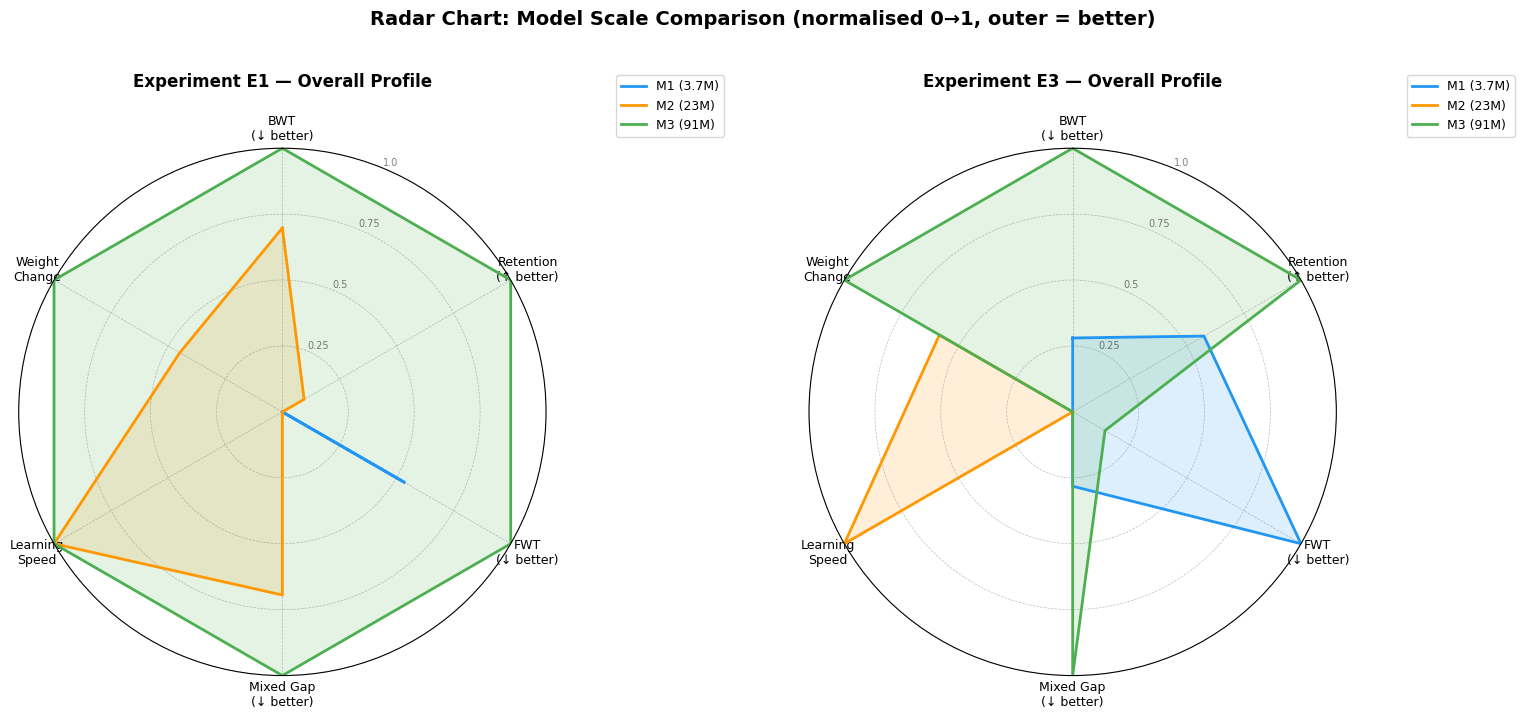

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

def normalise(series, invert=False):
    """Min-max normalise. If invert, flip so lower raw = higher score."""
    s   = pd.to_numeric(series, errors='coerce')
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series([0.5] * len(s), index=s.index)
    norm = (s - mn) / (mx - mn)
    return 1 - norm if invert else norm


def radar_chart(ax, categories, model_data, title):
    N      = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close polygon

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7, alpha=0.5)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

    for model, vals, color in model_data:
        v = vals + vals[:1]
        ax.plot(angles, v, color=color, linewidth=2, linestyle='solid', label=model)
        ax.fill(angles, v, color=color, alpha=0.15)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          subplot_kw=dict(polar=True))

# Radar axes definition
categories = ['BWT\n(↓ better)', 'Retention\n(↑ better)', 'FWT\n(↓ better)',
              'Mixed Gap\n(↓ better)', 'Learning\nSpeed', 'Weight\nChange']

for ax, exp in zip(axes, ['E1', 'E3']):
    bwt_col  = 'BWT_A_val'  if exp == 'E1' else 'BWT_B_val'
    ret_col  = 'Ret_A_val'  if exp == 'E1' else 'Ret_B_val'
    fwt_col  = 'FWT_B_val'  if exp == 'E1' else 'FWT_A_val'
    gap_col  = 'Gap_A_val'  if exp == 'E1' else 'Gap_B_val'

    stage_lbl = 'after_A' if exp == 'E1' else 'after_B'

    bwt_n  = normalise(metrics[bwt_col],  invert=True)
    ret_n  = normalise(metrics[ret_col],  invert=False)
    fwt_n  = normalise(metrics[fwt_col],  invert=True)
    gap_n  = normalise(metrics[gap_col],  invert=True)

    speed_sub = speed[(speed['experiment'] == exp) & (speed['stage'] == stage_lbl)]
    speed_map = dict(zip(speed_sub['model'], speed_sub['steps_to_ppl100']))
    speed_vals = pd.Series([speed_map.get(m, np.nan) for m in metrics['model']])
    speed_n    = normalise(speed_vals, invert=True)

    wc_sub  = wchange[wchange['experiment'] == exp]
    wc_map  = wc_sub.groupby('model')['avg_rel_change'].mean()
    wc_vals = pd.Series([wc_map.get(m, np.nan) for m in metrics['model']])
    wc_n    = normalise(wc_vals, invert=True)

    model_data = []
    for i, model in enumerate(metrics['model']):
        vals = [
            bwt_n.iloc[i],
            ret_n.iloc[i],
            fwt_n.iloc[i],
            gap_n.iloc[i],
            speed_n.iloc[i],
            wc_n.iloc[i],
        ]
        vals = [0.0 if np.isnan(v) else v for v in vals]
        model_data.append((f'{model} ({MODEL_PARAMS[model]}M)', vals, COLORS[model]))

    radar_chart(ax, categories, model_data,
                f'Experiment {exp} — Overall Profile')

plt.suptitle('Radar Chart: Model Scale Comparison (normalised 0→1, outer = better)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'plot10_radar.png'), dpi=150, bbox_inches='tight')
plt.show()


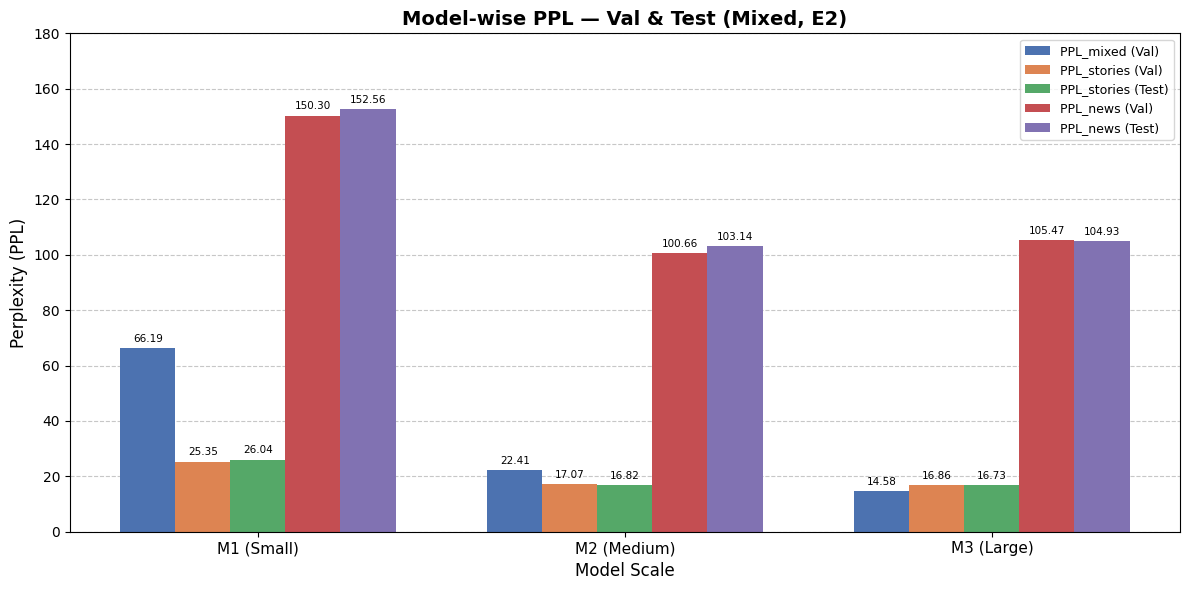

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
models = ['M1 (Small)', 'M2 (Medium)', 'M3 (Large)']

ppl_mixed_val   = [66.190, 22.41, 14.58]
ppl_stories_val = [25.35,  17.07, 16.86]
ppl_stories_test= [26.04,  16.82, 16.73]
ppl_news_val    = [150.30, 100.66, 105.47]
ppl_news_test   = [152.56, 103.14, 104.93]

x = np.arange(len(models))
width = 0.15  # width of each bar

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - 2*width, ppl_mixed_val,    width, label='PPL_mixed (Val)',    color='#4C72B0')
bars2 = ax.bar(x - 1*width, ppl_stories_val,  width, label='PPL_stories (Val)',  color='#DD8452')
bars3 = ax.bar(x + 0*width, ppl_stories_test, width, label='PPL_stories (Test)', color='#55A868')
bars4 = ax.bar(x + 1*width, ppl_news_val,     width, label='PPL_news (Val)',     color='#C44E52')
bars5 = ax.bar(x + 2*width, ppl_news_test,    width, label='PPL_news (Test)',    color='#8172B2')

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Model Scale', fontsize=12)
ax.set_ylabel('Perplexity (PPL)', fontsize=12)
ax.set_title('Model-wise PPL — Val & Test (Mixed, E2)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 180)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ppl_bar_chart.png', dpi=150)
plt.show()

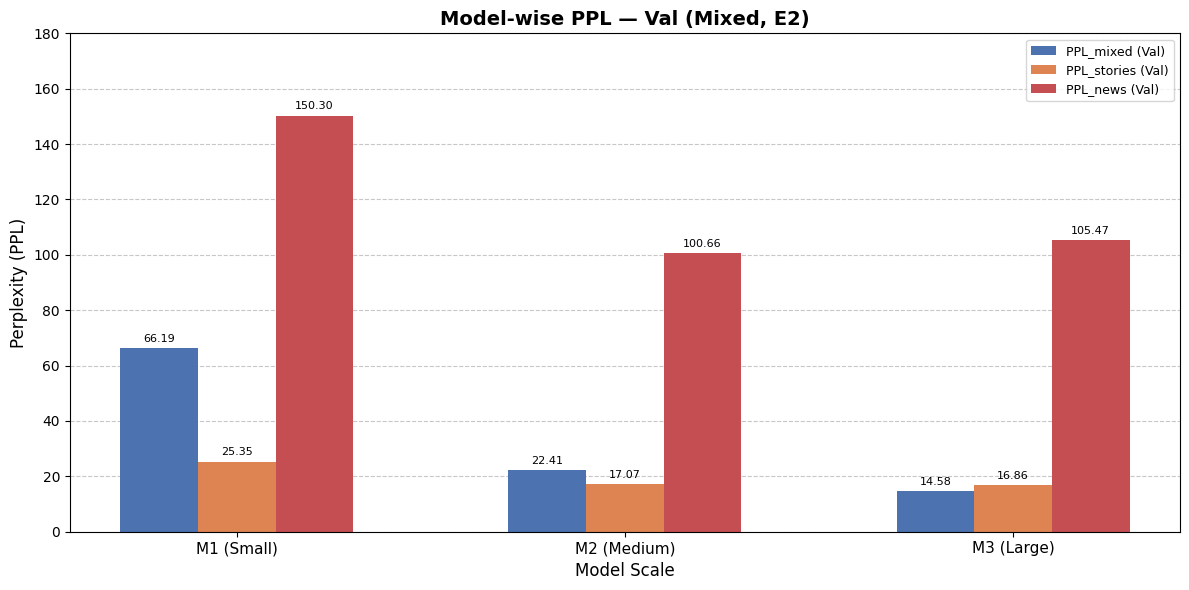

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
models = ['M1 (Small)', 'M2 (Medium)', 'M3 (Large)']

ppl_mixed_val   = [66.190, 22.41, 14.58]
ppl_stories_val = [25.35,  17.07, 16.86]
ppl_news_val    = [150.30, 100.66, 105.47]

x = np.arange(len(models))
width = 0.2  # slightly wider since fewer bars

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, ppl_mixed_val,   width, label='PPL_mixed (Val)',   color='#4C72B0')
bars2 = ax.bar(x,         ppl_stories_val, width, label='PPL_stories (Val)', color='#DD8452')
bars3 = ax.bar(x + width, ppl_news_val,    width, label='PPL_news (Val)',    color='#C44E52')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model Scale', fontsize=12)
ax.set_ylabel('Perplexity (PPL)', fontsize=12)
ax.set_title('Model-wise PPL — Val (Mixed, E2)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 180)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('ppl_bar_chart_val_only.png', dpi=150)
plt.show()

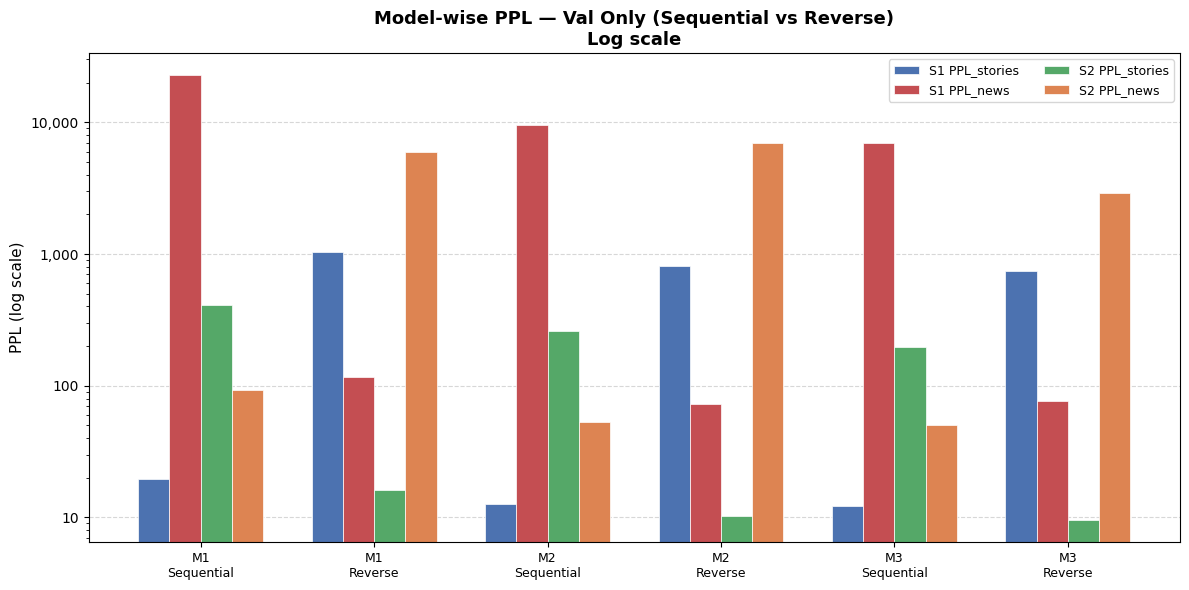

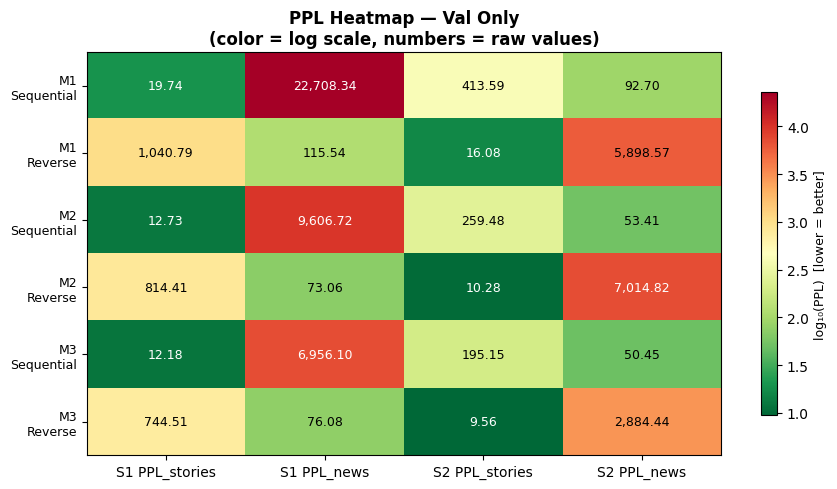

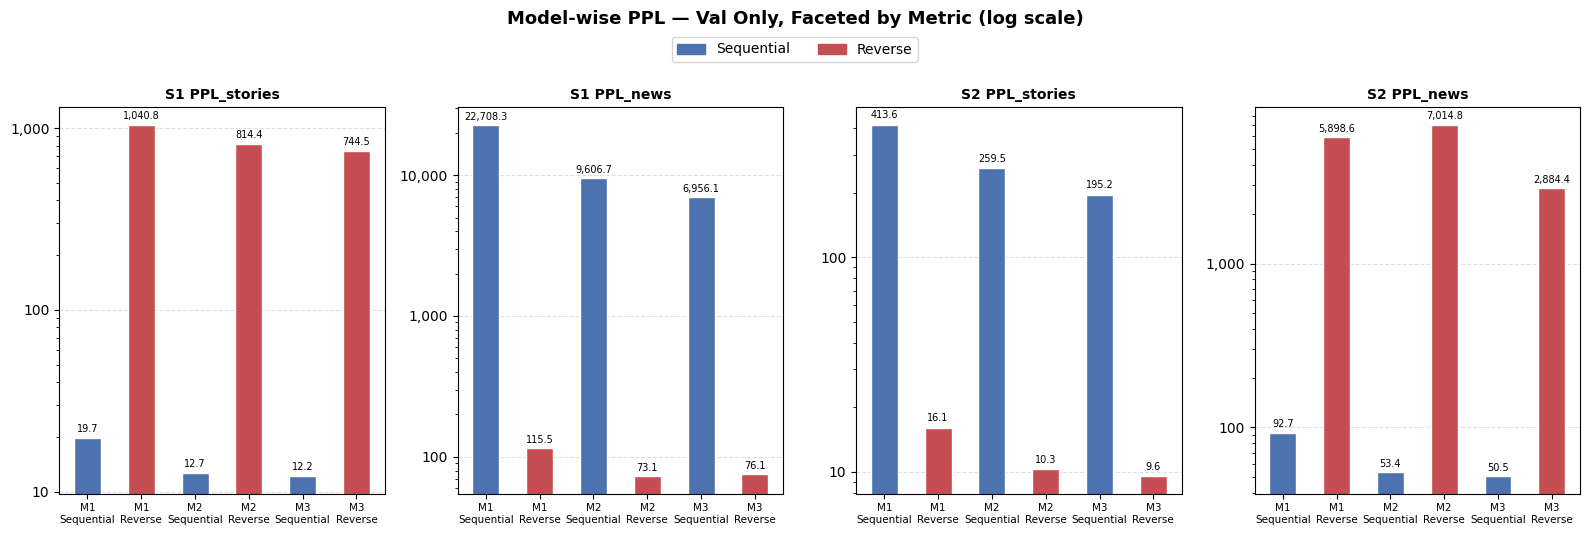

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Data (Val only) ──────────────────────────────────────────────────────────
data = {
    'Model':  ['M1','M1','M2','M2','M3','M3'],
    'Order':  ['Sequential','Reverse','Sequential','Reverse','Sequential','Reverse'],
    'S1_Stories_Val': [19.74, 1040.79, 12.73, 814.41, 12.18, 744.51],
    'S1_News_Val':    [22708.34, 115.54, 9606.72, 73.06, 6956.10, 76.08],
    'S2_Stories_Val': [413.59, 16.08, 259.48, 10.28, 195.15, 9.56],
    'S2_News_Val':    [92.70, 5898.57, 53.41, 7014.82, 50.45, 2884.44],
}
df = pd.DataFrame(data)
df['Label'] = df['Model'] + '\n' + df['Order']

metrics = [
    ('S1_Stories_Val', 'S1 PPL_stories'),
    ('S1_News_Val',    'S1 PPL_news'),
    ('S2_Stories_Val', 'S2 PPL_stories'),
    ('S2_News_Val',    'S2 PPL_news'),
]

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Log-scale grouped bar chart
# ════════════════════════════════════════════════════════════════════════════
colors = ['#4C72B0', '#C44E52', '#55A868', '#DD8452']

fig1, ax = plt.subplots(figsize=(12, 6))
x      = np.arange(len(df))
n_bars = len(metrics)
width  = 0.18
offsets= np.linspace(-(n_bars-1)/2, (n_bars-1)/2, n_bars) * width

for i, ((col, label), color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + offsets[i], df[col], width, label=label,
                  color=color, edgecolor='white', linewidth=0.5)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_xticks(x)
ax.set_xticklabels(df['Label'], fontsize=9)
ax.set_ylabel('PPL (log scale)', fontsize=11)
ax.set_title('Model-wise PPL — Val Only (Sequential vs Reverse)\nLog scale',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('plot1_log_bar_val.png', dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Heatmap
# ════════════════════════════════════════════════════════════════════════════
heat_cols   = [c for c, _ in metrics]
heat_labels = [l for _, l in metrics]
heat_df     = df.set_index('Label')[heat_cols]
heat_df.columns = heat_labels

fig2, ax2 = plt.subplots(figsize=(9, 5))
log_vals = np.log10(heat_df.values.astype(float))

im = ax2.imshow(log_vals, aspect='auto', cmap='RdYlGn_r')

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        val = heat_df.values[i, j]
        txt = f'{val:,.2f}' if val >= 100 else f'{val:.2f}'
        ax2.text(j, i, txt, ha='center', va='center', fontsize=9,
                 color='black' if 1.5 < log_vals[i, j] < 3.8 else 'white')

ax2.set_xticks(range(len(heat_labels)))
ax2.set_xticklabels(heat_labels, fontsize=10)
ax2.set_yticks(range(len(df)))
ax2.set_yticklabels(df['Label'], fontsize=9)
cbar = fig2.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('log₁₀(PPL)  [lower = better]', fontsize=9)
ax2.set_title('PPL Heatmap — Val Only\n(color = log scale, numbers = raw values)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_heatmap_val.png', dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Faceted subplots (1×4 grid, one panel per metric)
# ════════════════════════════════════════════════════════════════════════════
bar_colors = ['#4C72B0' if 'Sequential' in o else '#C44E52' for o in df['Order']]

fig3, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax3, (col, label) in zip(axes, metrics):
    bars = ax3.bar(df['Label'], df[col], color=bar_colors, edgecolor='white', width=0.5)
    ax3.set_title(label, fontsize=10, fontweight='bold')
    ax3.set_yscale('log')
    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax3.tick_params(axis='x', labelsize=7.5)
    ax3.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax3.set_axisbelow(True)
    for bar in bars:
        h = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width() / 2, h * 1.05,
                 f'{h:,.1f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_els = [Patch(color='#4C72B0', label='Sequential'),
              Patch(color='#C44E52', label='Reverse')]
fig3.legend(handles=legend_els, loc='upper center', ncol=2, fontsize=10,
            bbox_to_anchor=(0.5, 1.02))
fig3.suptitle('Model-wise PPL — Val Only, Faceted by Metric (log scale)',
              fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig('plot3_faceted_val.png', dpi=150, bbox_inches='tight')
plt.show()

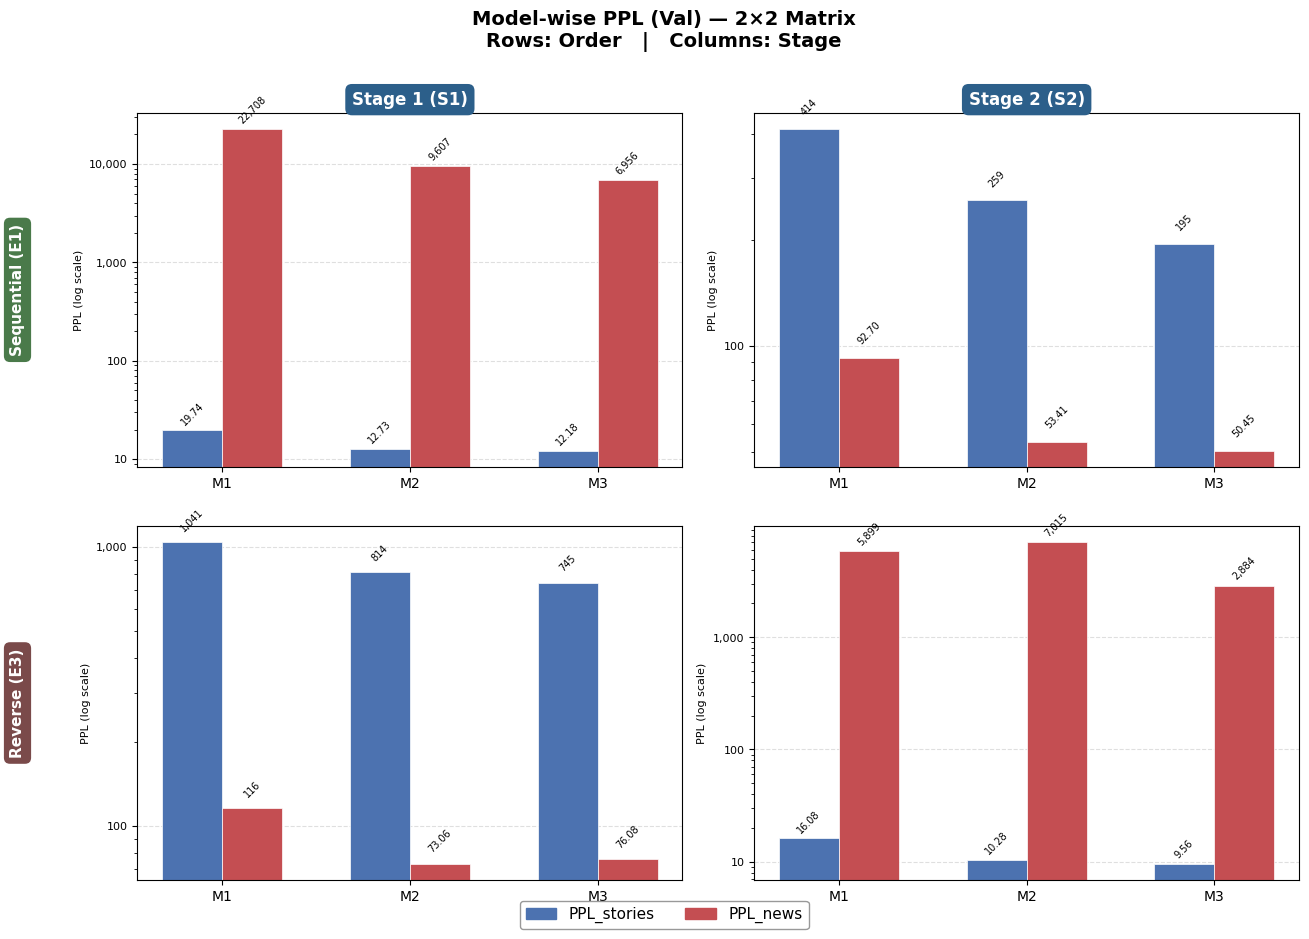

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Data (Val only)
data = {
    'Model':          ['M1', 'M2', 'M3'],
    # Sequential
    'Seq_S1_Stories': [19.74,   12.73,   12.18],
    'Seq_S1_News':    [22708.34, 9606.72, 6956.10],
    'Seq_S2_Stories': [413.59,  259.48,  195.15],
    'Seq_S2_News':    [92.70,    53.41,   50.45],
    # Reverse
    'Rev_S1_Stories': [1040.79, 814.41,  744.51],
    'Rev_S1_News':    [115.54,   73.06,   76.08],
    'Rev_S2_Stories': [16.08,    10.28,    9.56],
    'Rev_S2_News':    [5898.57, 7014.82, 2884.44],
}
df = pd.DataFrame(data)
models = df['Model'].tolist()

# 2×2 matrix: rows = Order, cols = Stage
# Each quadrant: grouped bars per model (Stories vs News)
quadrants = [
    # (row, col,  stories_col,       news_col,         title)
    (0, 0, 'Seq_S1_Stories', 'Seq_S1_News', 'Stage 1  |  Sequential'),
    (0, 1, 'Seq_S2_Stories', 'Seq_S2_News', 'Stage 2  |  Sequential'),
    (1, 0, 'Rev_S1_Stories', 'Rev_S1_News', 'Stage 1  |  Reverse'),
    (1, 1, 'Rev_S2_Stories', 'Rev_S2_News', 'Stage 2  |  Reverse'),
]

col_labels = ['Stage 1 (S1)', 'Stage 2 (S2)']
row_labels  = ['Sequential (E1)',   'Reverse (E3)']

STORY_COLOR = '#4C72B0'
NEWS_COLOR  = '#C44E52'

x      = np.arange(len(models))
width  = 0.32

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, col, stories_col, news_col, title in quadrants:
    ax = axes[row][col]

    stories_vals = df[stories_col].tolist()
    news_vals    = df[news_col].tolist()

    bars1 = ax.bar(x - width/2, stories_vals, width,
                   label='PPL_stories', color=STORY_COLOR,
                   edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, news_vals, width,
                   label='PPL_news', color=NEWS_COLOR,
                   edgecolor='white', linewidth=0.5)

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylabel('PPL (log scale)', fontsize=8)

    # Value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            label_txt = f'{h:,.0f}' if h >= 100 else f'{h:.2f}'
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.08,
                    label_txt, ha='center', va='bottom',
                    fontsize=7, rotation=45)

# Column headers (Stage)
for col_idx, col_label in enumerate(col_labels):
    axes[0][col_idx].set_title(col_label, fontsize=12, fontweight='bold',
                                color='white', pad=6,
                                bbox=dict(boxstyle='round,pad=0.4',
                                          facecolor='#2C5F8A', edgecolor='none'))

#  Row headers (Order)
row_colors = ['#4A7A4A', '#7A4A4A']
for row_idx, (row_label, rc) in enumerate(zip(row_labels, row_colors)):
    axes[row_idx][0].annotate(
        row_label, xy=(-0.22, 0.5), xycoords='axes fraction',
        fontsize=11, fontweight='bold', color='white',
        va='center', ha='center', rotation=90,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=rc, edgecolor='none')
    )

# Legend
legend_els = [Patch(color=STORY_COLOR, label='PPL_stories'),
              Patch(color=NEWS_COLOR,  label='PPL_news')]
fig.legend(handles=legend_els, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.02),
           frameon=True, edgecolor='grey')

fig.suptitle('Model-wise PPL (Val) — 2×2 Matrix\nRows: Order   |   Columns: Stage',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('plot_2x2_order_domain.png', dpi=150, bbox_inches='tight')
plt.show()

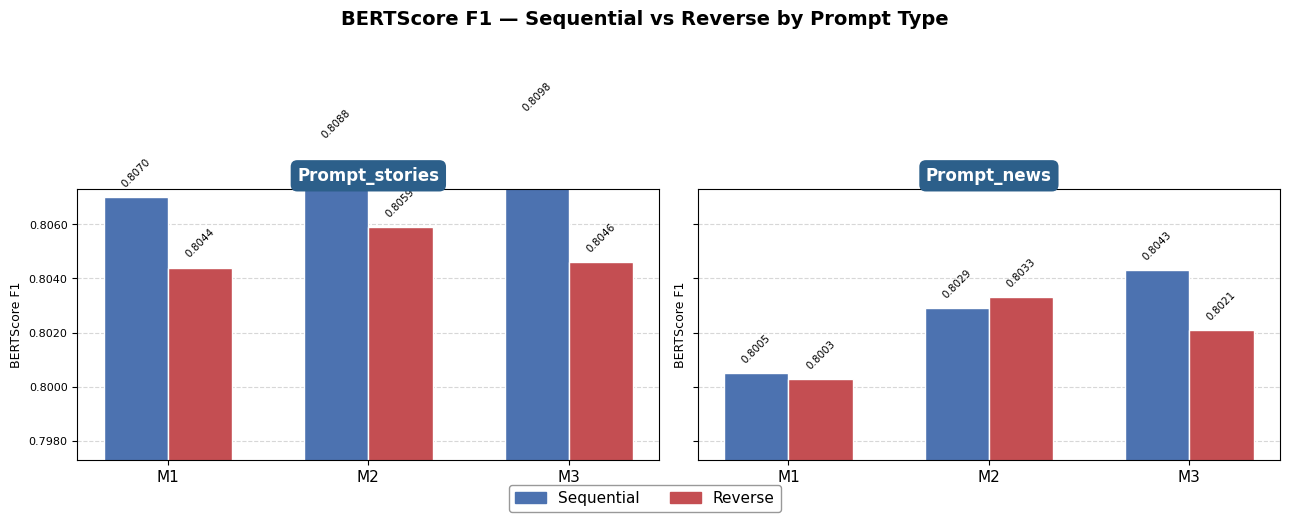

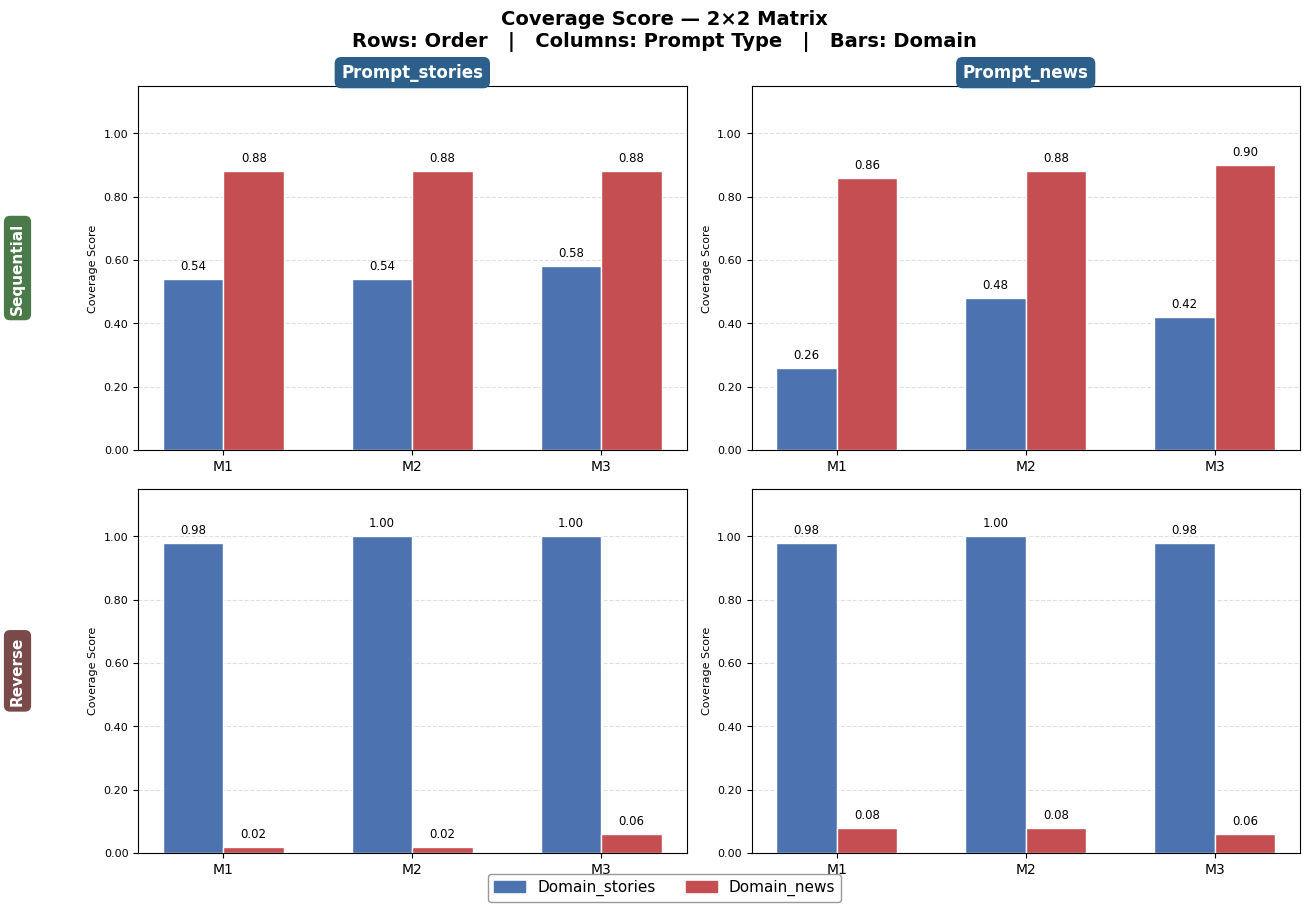

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Data
data = {
    'Model': ['M1', 'M1', 'M2', 'M2', 'M3', 'M3'],
    'Order': ['Sequential', 'Reverse', 'Sequential', 'Reverse', 'Sequential', 'Reverse'],
    # BERTScore F1
    'BERT_Stories': [0.807,  0.8044, 0.8088, 0.8059, 0.8098, 0.8046],
    'BERT_News':    [0.8005, 0.8003, 0.8029, 0.8033, 0.8043, 0.8021],
    # Coverage Score
    'Cov_Ps_Ds': [0.54, 0.98, 0.54, 1.00, 0.58, 1.00],  # Prompt_stories → Domain_stories
    'Cov_Ps_Dn': [0.88, 0.02, 0.88, 0.02, 0.88, 0.06],  # Prompt_stories → Domain_news
    'Cov_Pn_Ds': [0.26, 0.98, 0.48, 1.00, 0.42, 0.98],  # Prompt_news    → Domain_stories
    'Cov_Pn_Dn': [0.86, 0.08, 0.88, 0.08, 0.90, 0.06],  # Prompt_news    → Domain_news
}
df = pd.DataFrame(data)

models    = ['M1', 'M2', 'M3']
SEQ_MASK  = df['Order'] == 'Sequential'
REV_MASK  = df['Order'] == 'Reverse'

SEQ_COLOR    = '#4C72B0'
REV_COLOR    = '#C44E52'
STORY_COLOR  = '#4C72B0'
NEWS_COLOR   = '#C44E52'

x     = np.arange(len(models))
width = 0.32


# ════════════════════════════════════════════════════════════════════════════
# CHART 1 — BERTScore F1
# ════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

bert_quadrants = [
    (0, 'BERT_Stories', 'Prompt_stories'),
    (1, 'BERT_News',    'Prompt_news'),
]

for col_idx, col, title in bert_quadrants:
    ax = axes1[col_idx]

    seq_vals = df[SEQ_MASK][col].tolist()
    rev_vals = df[REV_MASK][col].tolist()

    b1 = ax.bar(x - width/2, seq_vals, width, label='Sequential',
                color=SEQ_COLOR, edgecolor='white')
    b2 = ax.bar(x + width/2, rev_vals, width, label='Reverse',
                color=REV_COLOR, edgecolor='white')

    # Zoom y-axis to highlight small differences
    all_vals = seq_vals + rev_vals
    y_min = min(all_vals) - 0.003
    y_max = max(all_vals) + 0.003
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.set_ylabel('BERTScore F1', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', color='white', pad=6,
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='#2C5F8A', edgecolor='none'))

    # Value labels
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.0003, f'{h:.4f}',
                    ha='center', va='bottom', fontsize=7.5, rotation=45)

legend_els1 = [Patch(color=SEQ_COLOR, label='Sequential'),
               Patch(color=REV_COLOR,  label='Reverse')]
fig1.legend(handles=legend_els1, loc='lower center', ncol=2,
            fontsize=11, bbox_to_anchor=(0.5, -0.04), frameon=True, edgecolor='grey')
fig1.suptitle('BERTScore F1 — Sequential vs Reverse by Prompt Type',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_bertscore.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# CHART 2 — Coverage Score  (2×2: rows = Order, cols = Prompt type)
#            Each quadrant: bars = Domain_stories vs Domain_news
# ════════════════════════════════════════════════════════════════════════════
cov_quadrants = [
    # (row, col,  stories_col,  news_col,       col_header    )
    (0, 0, 'Cov_Ps_Ds', 'Cov_Ps_Dn', 'Prompt_stories'),
    (0, 1, 'Cov_Pn_Ds', 'Cov_Pn_Dn', 'Prompt_news'),
    (1, 0, 'Cov_Ps_Ds', 'Cov_Ps_Dn', 'Prompt_stories'),
    (1, 1, 'Cov_Pn_Ds', 'Cov_Pn_Dn', 'Prompt_news'),
]

row_masks   = [SEQ_MASK, REV_MASK]
row_labels  = ['Sequential', 'Reverse']
col_labels  = ['Prompt_stories', 'Prompt_news']
row_colors  = ['#4A7A4A', '#7A4A4A']

fig2, axes2 = plt.subplots(2, 2, figsize=(13, 9))

for row_idx, order_mask, order_label in zip(range(2), row_masks, row_labels):
    for col_idx, (ds_col, dn_col, col_label) in enumerate([
        ('Cov_Ps_Ds', 'Cov_Ps_Dn', 'Prompt_stories'),
        ('Cov_Pn_Ds', 'Cov_Pn_Dn', 'Prompt_news'),
    ]):
        ax = axes2[row_idx][col_idx]

        ds_vals = df[order_mask][ds_col].tolist()
        dn_vals = df[order_mask][dn_col].tolist()

        b1 = ax.bar(x - width/2, ds_vals, width, label='Domain_stories',
                    color=STORY_COLOR, edgecolor='white')
        b2 = ax.bar(x + width/2, dn_vals, width, label='Domain_news',
                    color=NEWS_COLOR,  edgecolor='white')

        ax.set_ylim(0, 1.15)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=10)
        ax.tick_params(axis='y', labelsize=8)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)
        ax.set_axisbelow(True)
        ax.set_ylabel('Coverage Score', fontsize=8)

        # Value labels
        for bars in [b1, b2]:
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.02, f'{h:.2f}',
                        ha='center', va='bottom', fontsize=8.5)

# Column headers
for col_idx, col_label in enumerate(col_labels):
    axes2[0][col_idx].set_title(col_label, fontsize=12, fontweight='bold',
                                 color='white', pad=6,
                                 bbox=dict(boxstyle='round,pad=0.4',
                                           facecolor='#2C5F8A', edgecolor='none'))

# Row headers
for row_idx, (row_label, rc) in enumerate(zip(row_labels, row_colors)):
    axes2[row_idx][0].annotate(
        row_label, xy=(-0.22, 0.5), xycoords='axes fraction',
        fontsize=11, fontweight='bold', color='white',
        va='center', ha='center', rotation=90,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=rc, edgecolor='none')
    )

legend_els2 = [Patch(color=STORY_COLOR, label='Domain_stories'),
               Patch(color=NEWS_COLOR,  label='Domain_news')]
fig2.legend(handles=legend_els2, loc='lower center', ncol=2,
            fontsize=11, bbox_to_anchor=(0.5, -0.02), frameon=True, edgecolor='grey')
fig2.suptitle('Coverage Score — 2×2 Matrix\nRows: Order   |   Columns: Prompt Type   |   Bars: Domain',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_coverage.png', dpi=150, bbox_inches='tight')
plt.show()